In [1]:
import numpy as np
import skimage
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import pandas as pd
from skimage.filters.rank import entropy
from skimage.morphology import disk

In [2]:
file_list = glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/*/Carboplatin.tiff')
file_list = pd.DataFrame(file_list,columns = ['path'])
file_list['acquisition_ID'] = file_list.path.str.split('/').str[-2]
file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()

biosamples_path = '~/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)

In [3]:
file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient

In [ ]:
def frac_zeros_image(file):
    '''Return the fraction of pixels ==0'''
    img = skimage.io.imread(file)    
    return np.count_nonzero(img==0)/(img.shape[0]*img.shape[1])
def mean_entropy(file):
    img = skimage.io.imread(file)
    img = skimage.exposure.rescale_intensity(img,in_range=(0, 1))
    return entropy(img,disk(5)).mean()
file_list['empty_pixel_frac'] = file_list.path.map(frac_zeros_image)
file_list['mean_entropy'] = file_list.path.map(mean_entropy)


/home/giuseppe/anaconda3/lib/python3.9/site-packages/pandas/core/algorithms.py:1814: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return lib.map_infer(values, mapper, convert=convert)


In [ ]:
a = file_list[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','empty_pixel_frac','mean_entropy']].sort_values('mean_entropy',ascending=False)
plt.scatter(a.empty_pixel_frac ,a.mean_entropy,color = np.where(a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE','red','green'),s = 0.5)
a

In [ ]:
file_list[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','mean_entropy']].sort_values('mean_entropy',ascending=False).to_csv('Carboplatin_acquisition_ID.csv')

In [ ]:

img = skimage.io.imread(file_list.path[763])
img = skimage.exposure.rescale_intensity(img,in_range=(0, 1))

In [ ]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
f = ax0.imshow(img)
fig.colorbar(f, ax=ax0)
f = ax1.imshow(entropy(img,disk(5)))
fig.colorbar(f, ax=ax1)

(113.12021, 0.069199674)

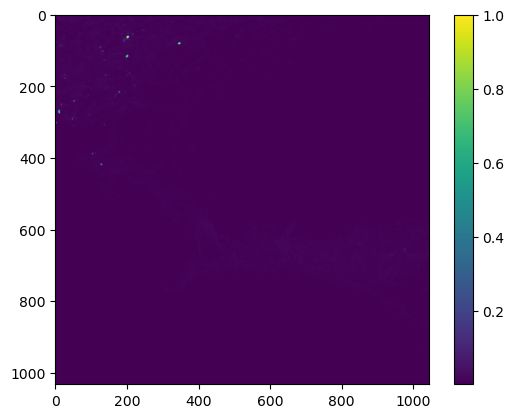

In [32]:
a = skimage.io.imread(file_list.path[763])
plt.imshow(a/a.max())
plt.colorbar()
a.max(),a.min()

In [22]:
file_list = glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/*/Carboplatin.tiff')
file_list = pd.DataFrame(file_list,columns = ['path'])
file_list['acquisition_ID'] = file_list.path.str.split('/').str[-2]
file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()

biosamples_path = '~/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)
file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


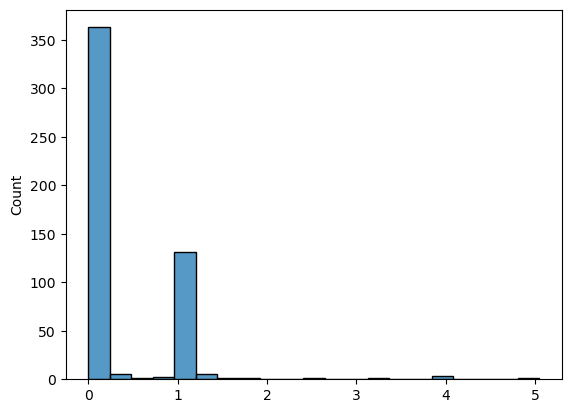

In [41]:
data = []
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].path:
    img = skimage.io.imread(file)
    data+=[np.quantile(img,q = 0.95)]
sns.histplot(data)
thr = np.quantile(data,q = 0.95)

In [42]:
thr

1.0

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

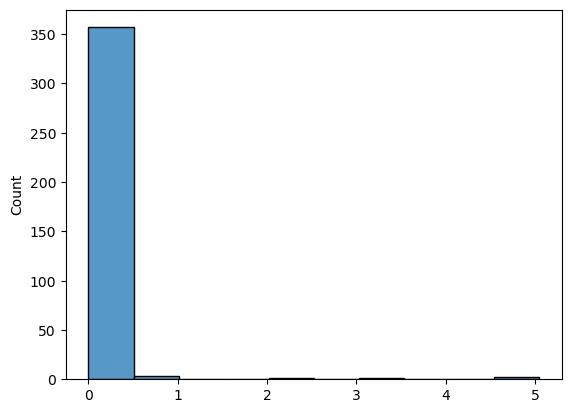

In [30]:
data = []
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].path:
    img = skimage.io.imread(file)
    data+=[np.quantile(img,q = 0.25)]
sns.histplot(data)

In [19]:
data = []
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].path:
    img = skimage.io.imread(file)
    data+=[np.quantile(img,q = 0.95)]
data


[1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.3821781277656555,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 5.047067642211914,
 0.0,
 3.2738797664642334,
 0.0,
 0.0,
 4.0,
 0.0,
 0.0,
 0.0,
 3.870743751525879,
 3.959897041320801,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0465290546417236,
 1.2542552947998047,
 1.0,
 1.0193192958831787,
 1.0,
 1.1971317529678345,
 1.1299965381622314,
 1.0806434154510498,
 1.1906766891479492,
 1.0,
 1.0,
 1.2694069147109985,
 1.2230334281921387,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.7721147537231445,
 0.0,
 0.0,
 1.0,
 1.2947657108306885,
 1.0109559297561646

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

[]

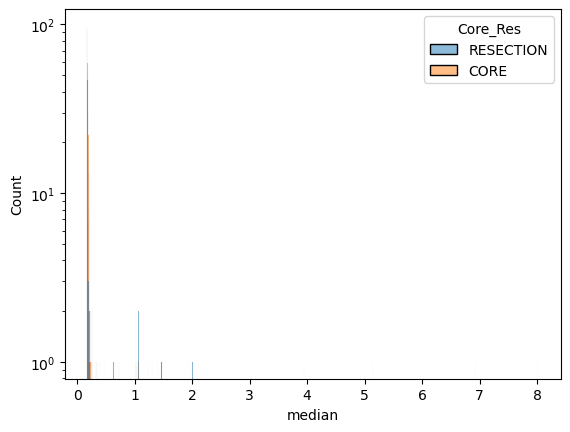

In [10]:
sns.histplot(a,x = 'median',hue = 'Core_Res')
plt.semilogy()

In [17]:
np.quantile(img,q = 0.9)

0.20547139048576354